## Part 2: Clustering
Datasets:
- worldbank_2017_2021.csv
- countries_regions.xlsx

In [1]:
import os
os.chdir('/Users/thammapatrattanataipop/year3term2/stat/project')
os.getcwd()

'/Users/thammapatrattanataipop/year3term2/stat/project'

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


## 2. Load Datasets

In [7]:
df_gender = pd.read_csv('worldbank_2017_2021.csv')
df_region = pd.read_excel('countries_regions.xlsx')

df_gender.head(), df_region.head()

(     Country Name  Year  \
 0     Afghanistan  2017   
 1         Albania  2017   
 2         Algeria  2017   
 3  American Samoa  2017   
 4         Andorra  2017   
 
    Agricultural irrigated land (% of total agricultural land)  \
 0                                               5.99            
 1                                              14.56            
 2                                               3.16            
 3                                                NaN            
 4                                                NaN            
 
    Agricultural land (% of land area)  \
 0                               58.12   
 1                               42.86   
 2                               17.36   
 3                               13.90   
 4                               40.04   
 
    Agriculture, forestry, and fishing, value added (% of GDP)  \
 0                                              26.42            
 1                                            

## 3. Merge Datasets

In [8]:
print(df_gender.columns)
print(df_region.columns)

Index(['Country Name', 'Year',
       'Agricultural irrigated land (% of total agricultural land)',
       'Agricultural land (% of land area)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Arable land (% of land area)', 'Cereal yield (kg per hectare)',
       'Crop production index (2014-2016 = 100)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Food production index (2014-2016 = 100)',
       ...
       'Merchandise exports (current US$)',
       'Merchandise imports (current US$)', 'Merchandise trade (% of GDP)',
       'Contributing family workers, female (% of female employment) (modeled ILO estimate)',
       'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
       'Firms with female participation in ownership (% of firms)',
       'Firms with female top manager (% of firms)',
       'Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)',
       'Pro

In [9]:
df = pd.merge(
    df_gender,
    df_region,
    left_on='Country Name',
    right_on='CountryName',
    how='inner'
)

df.shape

(1070, 198)

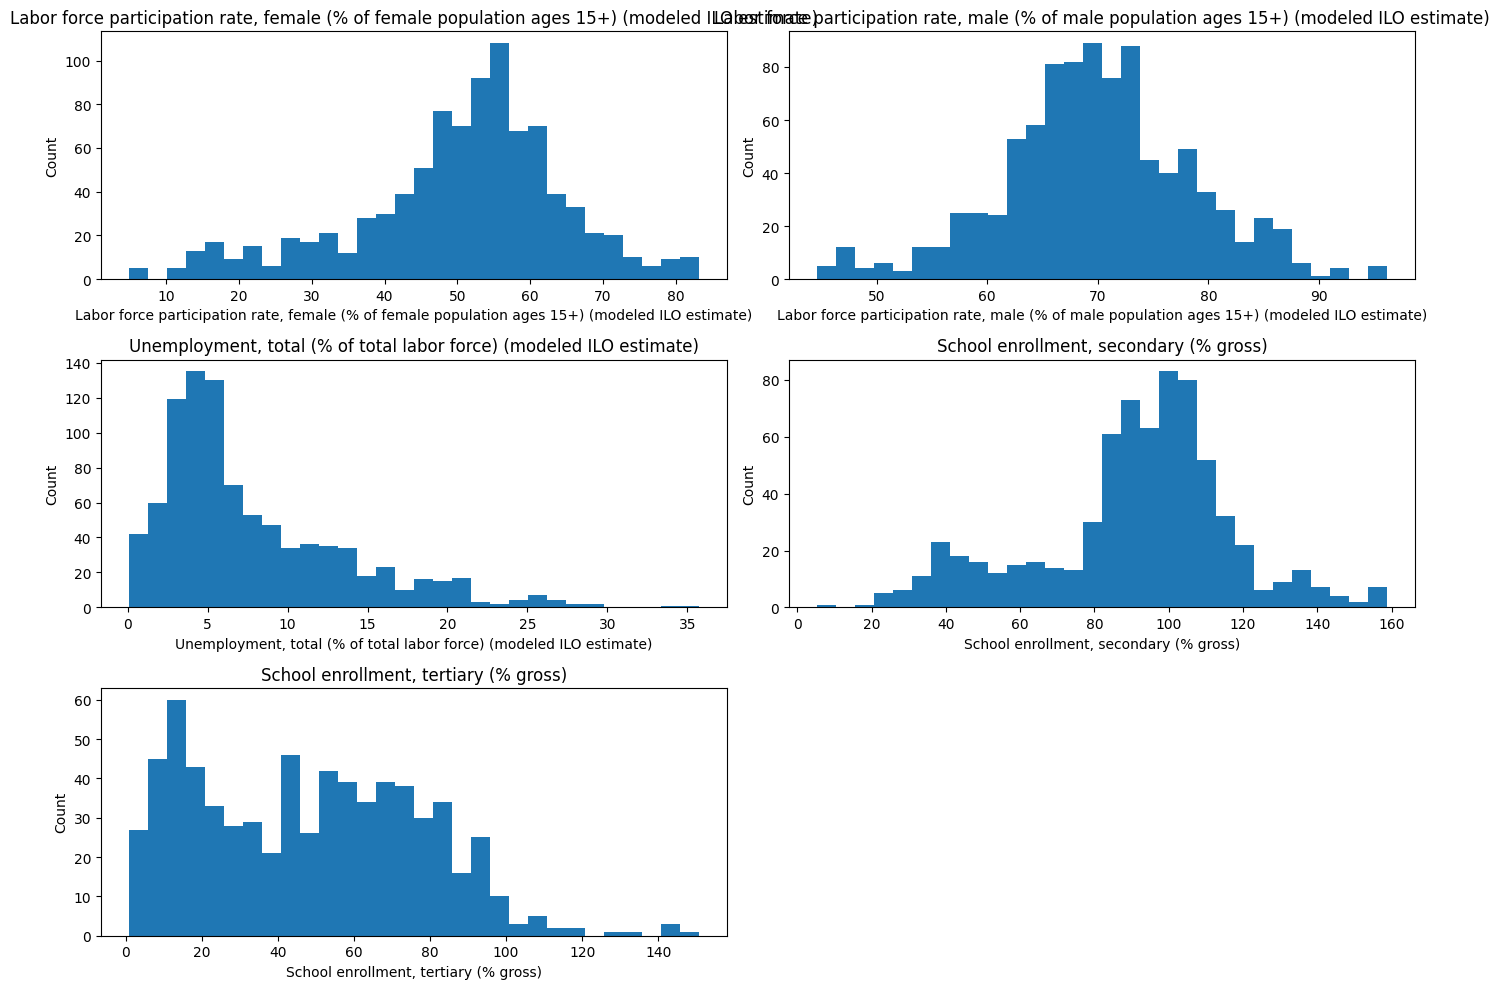

In [10]:
#perform eda
import matplotlib.pyplot as plt

features = [
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
    'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Initial Data Inspection

In [11]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Columns: 198 entries, Country Name to ThirdWorld
dtypes: float64(193), int64(1), object(4)
memory usage: 1.6+ MB


,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",CountryName,Region,ThirdWorld
count,1070,1070.000000,249.000000,1035.000000,961.000000,1020.00000,881.00000,960.000000,967.000000,960.000000,...,920.000000,920.000000,74.000000,74.000000,19.000000,19.000000,33.000000,1070,1070,1070
unique,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214,13,2
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Africa,No
freq,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,265,840
mean,NaN,2019.000000,13.004217,37.366174,9.984839,13.95899,3688.24790,105.311260,384.782782,106.028167,...,12.033783,5.270924,34.682432,17.718919,17.334211,7.074211,52.090909,NaN,NaN,NaN
std,NaN,1.414875,16.710852,22.244828,10.086568,13.72012,3380.74777,16.656407,5970.284777,14.938821,...,16.195977,7.276254,15.024166,8.749727,3.714803,2.891367,24.930608,NaN,NaN,NaN
min,NaN,2017.000000,0.000000,0.500000,0.010000,0.05000,0.10000,46.900000,0.000000,56.750000,...,0.000000,0.000000,5.200000,0.900000,11.610000,2.610000,5.300000,NaN,NaN,NaN
25%,NaN,2018.000000,1.300000,19.020000,2.090000,3.06750,1653.00000,96.772500,20.720000,98.877500,...,0.890000,0.487500,25.150000,12.100000,14.645000,4.860000,28.600000,NaN,NaN,NaN
50%,NaN,2019.000000,8.100000,38.530000,6.590000,10.19000,3021.00000,103.655000,88.660000,104.000000,...,4.250000,1.990000,34.550000,17.400000,17.310000,7.030000,58.200000,NaN,NaN,NaN
75%,NaN,2020.000000,16.540000,53.400000,16.030000,20.14500,4813.00000,112.435000,182.410000,111.980000,...,17.402500,7.730000,43.925000,21.675000,19.125000,9.220000,65.600000,NaN,NaN,NaN


## 5. Missing Values Analysis

In [12]:
df.isnull().sum().sort_values(ascending=False)

Land area where elevation is below 5 meters (% of total land area)    1070
Children in employment, male (% of male children ages 7-14)           1070
Children in employment, female (% of female children ages 7-14)       1070
Energy imports, net (% of energy use)                                 1070
Children in employment, total (% of children ages 7-14)               1070
                                                                      ... 
Population ages 15-64 (% of total population)                            0
Population ages 0-14 (% of total population)                             0
Population, total                                                        0
Population growth (annual %)                                             0
ThirdWorld                                                               0
Length: 198, dtype: int64

In [13]:
# แยก numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# เอา Year ออก (ไม่ต้อง aggregate)
numeric_cols.remove('Year')

numeric_cols

['Agricultural irrigated land (% of total agricultural land)',
 'Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'CPIA public sector management and institutions cluster average (1=low to 6=high)',
 'Ease of doing business rank (1=most business-friendly regulations)',
 'Electric power consumption (kWh per capita)',
 'Energy use (kg of oil equivalent pe

In [14]:
# Aggregate numerical data by country
df_agg = (
    df
    .groupby('Country Name')[numeric_cols]
    .median()
    .reset_index()
)

df_agg.head()

,Country Name,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)"
0,Afghanistan,6.01,58.28,26.42,11.95,2099.0,115.78,10.970,109.41,1.85,...,8.500000e+08,6.777000e+09,41.53,60.87,12.20,NaN,NaN,NaN,NaN,NaN
1,Albania,15.25,42.85,18.43,22.26,5038.2,107.67,97.125,104.92,28.79,...,2.716000e+09,5.897000e+09,58.03,28.75,16.39,20.7,18.1,NaN,NaN,61.9
2,Algeria,3.25,17.35,11.24,3.16,1520.4,115.36,20.680,108.63,0.82,...,3.531200e+10,4.463200e+10,41.32,2.20,1.62,NaN,NaN,NaN,NaN,NaN
3,American Samoa,NaN,14.20,NaN,4.75,NaN,NaN,40.140,NaN,85.80,...,3.770000e+08,7.120000e+08,162.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,NaN,40.00,0.55,1.68,NaN,NaN,NaN,NaN,34.04,...,1.465000e+08,1.539000e+09,53.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Merge aggregated data with region information
df_agg = df_agg.merge(
    df_region,
    left_on='Country Name',
    right_on='CountryName',
    how='left'
)

df_agg.head()

,Country Name,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",CountryName,Region,ThirdWorld
0,Afghanistan,6.01,58.28,26.42,11.95,2099.0,115.78,10.970,109.41,1.85,...,60.87,12.20,NaN,NaN,NaN,NaN,NaN,Afghanistan,South Asia,Yes
1,Albania,15.25,42.85,18.43,22.26,5038.2,107.67,97.125,104.92,28.79,...,28.75,16.39,20.7,18.1,NaN,NaN,61.9,Albania,Eastern Europe,No
2,Algeria,3.25,17.35,11.24,3.16,1520.4,115.36,20.680,108.63,0.82,...,2.20,1.62,NaN,NaN,NaN,NaN,NaN,Algeria,Africa,No
3,American Samoa,NaN,14.20,NaN,4.75,NaN,NaN,40.140,NaN,85.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,NaN,40.00,0.55,1.68,NaN,NaN,NaN,NaN,34.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [16]:
# Define economic indicator used for analysis
target_col = 'GNI per capita, PPP (current international $)'

df_agg = df_agg.dropna(subset=[target_col])

df_agg[target_col].isnull().sum()

np.int64(0)

In [17]:
# หา numeric columns
numeric_cols = df_agg.select_dtypes(include=[np.number]).columns.tolist()

# เอา target ออก
numeric_cols.remove(target_col)

# หา column ที่ missing ทั้งหมด
all_missing_cols = [
    col for col in numeric_cols
    if df_agg[col].isna().all()
]

all_missing_cols

['Energy use (kg of oil equivalent per capita)',
 'Land area where elevation is below 5 meters (% of total land area)',
 'Population living in areas where elevation is below 5 meters (% of total population)',
 'International migrant stock, total',
 'Children in employment, female (% of female children ages 7-14)',
 'Children in employment, male (% of male children ages 7-14)',
 'Children in employment, total (% of children ages 7-14)',
 'Energy imports, net (% of energy use)']

In [18]:
# Remove columns with all missing values
df_agg = df_agg.drop(columns=all_missing_cols)

In [19]:
# Import imputer for handling missing data
from sklearn.impute import SimpleImputer

feature_cols = df_agg.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove(target_col)

imputer = SimpleImputer(strategy='median')
df_agg[feature_cols] = imputer.fit_transform(df_agg[feature_cols])

In [20]:
# Verify dataset after preprocessing
df_agg.info()
df_agg.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 194 entries, 0 to 213
Columns: 189 entries, Country Name to ThirdWorld
dtypes: float64(185), object(4)
memory usage: 288.0+ KB


,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)"
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,1.940000e+02,...,1.940000e+02,1.940000e+02,194.000000,194.000000,194.00000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,7.883479,37.943247,9.951933,14.222474,3671.772680,105.800825,238.024871,106.373402,31.913969,1.881116e+05,...,8.657587e+10,8.332485e+10,63.281082,10.826134,4.85134,34.600515,17.521649,17.287706,7.258428,57.160825
std,9.504545,22.065305,9.918424,13.661663,3067.376007,14.083121,1192.168369,12.860338,24.270085,7.548380e+05,...,2.449413e+11,2.168111e+11,39.126923,14.619248,6.86065,9.240250,5.383418,1.133896,0.868056,10.409049
min,0.000000,0.540000,0.020000,0.050000,16.300000,59.570000,0.000000,63.220000,0.000000,0.000000e+00,...,0.000000e+00,3.300000e+07,15.420000,0.000000,0.00000,5.200000,0.900000,11.610000,2.610000,5.300000
25%,6.125000,19.375000,2.320000,4.075000,1874.225000,98.200000,25.897500,100.470000,11.180000,2.550500e+03,...,1.257189e+09,2.601250e+09,40.565000,1.215000,0.63000,34.550000,17.400000,17.282500,7.265000,58.200000
50%,6.125000,39.025000,6.790000,10.385000,3171.300000,104.580000,90.090000,104.715000,30.120000,2.200000e+04,...,7.680000e+09,9.326500e+09,53.200000,4.830000,2.15000,34.550000,17.400000,17.282500,7.265000,58.200000
75%,6.125000,53.635000,15.327500,20.322500,4619.075000,112.245000,177.235000,111.905000,49.682500,9.820140e+04,...,4.676425e+10,5.110825e+10,71.065000,14.545000,6.01750,34.550000,17.400000,17.282500,7.265000,58.200000
max,78.780000,80.760000,58.930000,61.200000,28225.000000,166.280000,16383.810000,162.560000,97.490000,8.153116e+06,...,2.500000e+12,2.080000e+12,330.380000,67.130000,42.54000,70.400000,43.100000,27.770000,11.710000,96.200000


## Part 2.2

In [21]:
# Specify target variable for regression analysis
target_col = 'GNI per capita, PPP (current international $)'

df_agg['log_GNI'] = np.log(df_agg[target_col])

/var/folders/f1/tn8f4qbs6l79lhbg16lhkc940000gn/T/ipykernel_34557/1211457154.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_agg['log_GNI'] = np.log(df_agg[target_col])


In [22]:
# Define log-transformed GNI as regression target
y = df_agg['log_GNI']

X = df_agg.select_dtypes(include=[np.number]).drop(
    columns=[
        'GNI per capita, PPP (current international $)',
        'log_GNI'
    ]
)

In [23]:
# Check dimensions of feature matrix and target vector
X.shape, y.shape

((194, 184), (194,))

In [24]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## workflow 1 StandardScaler

In [25]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [26]:
# Compute correlation matrix between features and target
corr_df = pd.concat([X_train, y_train], axis=1).corr()

corr_with_target = corr_df['log_GNI'].drop('log_GNI')

selected_features_wf1 = corr_with_target[
    abs(corr_with_target) > 0.3
].index.tolist()

len(selected_features_wf1), selected_features_wf1

(81,
 ['Agricultural land (% of land area)',
  'Agriculture, forestry, and fishing, value added (% of GDP)',
  'Cereal yield (kg per hectare)',
  'Rural population (% of total population)',
  'Access to electricity (% of population)',
  'Ease of doing business rank (1=most business-friendly regulations)',
  'Mortality rate, under-5 (per 1,000 live births)',
  'Population growth (annual %)',
  'Population in urban agglomerations of more than 1 million (% of total population)',
  'Poverty headcount ratio at $2.15 a day (2017 PPP) (% of population)',
  'Prevalence of underweight, weight for age (% of children under 5)',
  'Primary completion rate, total (% of relevant age group)',
  'Renewable energy consumption (% of total final energy consumption)',
  'Urban population (% of total population)',
  'Exports of goods and services (% of GDP)',
  'Grants, excluding technical cooperation (BoP, current US$)',
  'Gross savings (% of GDP)',
  'Medium and high-tech manufacturing value added (% ma

In [27]:
# Select features for Workflow 1 based on correlation analysis
X_train_wf1 = X_train_scaled[:, X_train.columns.get_indexer(selected_features_wf1)]
X_test_wf1  = X_test_scaled[:, X_train.columns.get_indexer(selected_features_wf1)]

In [28]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
model_wf1 = LinearRegression()
model_wf1.fit(X_train_wf1, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
# Calculate RMSE for Workflow 1 model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

y_pred_wf1 = model_wf1.predict(X_test_wf1)

rmse_wf1 = np.sqrt(mean_squared_error(y_test, y_pred_wf1))
mape_wf1 = mean_absolute_percentage_error(y_test, y_pred_wf1)
r2_wf1   = r2_score(y_test, y_pred_wf1)

rmse_wf1, mape_wf1, r2_wf1

(np.float64(0.41908795672672344), 0.036151312660674936, 0.7564053277910208)

## Workflow 2 Feature Selection (Lasso)

In [33]:
# Import Lasso regression for feature selection
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train_scaled, y_train)

selected_features_wf2 = X_train.columns[lasso.coef_ != 0].tolist()

len(selected_features_wf2)

69

In [34]:
# Select features identified by Lasso for Workflow 2
X_train_wf2 = X_train[selected_features_wf2]
X_test_wf2  = X_test[selected_features_wf2]

X_train_wf2.shape, X_test_wf2.shape

((155, 69), (39, 69))

In [35]:
# Import Random Forest regressor for nonlinear modeling
from sklearn.ensemble import RandomForestRegressor

model_wf2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_wf2.fit(X_train_wf2, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
# Generate predictions for Workflow 2 on test data
y_pred_wf2 = model_wf2.predict(X_test_wf2)

rmse_wf2 = np.sqrt(mean_squared_error(y_test, y_pred_wf2))
mape_wf2 = mean_absolute_percentage_error(y_test, y_pred_wf2)
r2_wf2   = r2_score(y_test, y_pred_wf2)

rmse_wf2, mape_wf2, r2_wf2

(np.float64(0.346345404933238), 0.028602226233236168, 0.8336295144612902)